In [6]:
import kagglehub
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Download Food-11 dataset (~700 MB only)
path = kagglehub.dataset_download("trolukovich/food11-image-dataset")
print("Path:", path)
print("Contents:", os.listdir(path))

# Paths
train_dir = os.path.join(path, "training")
val_dir   = os.path.join(path, "validation")
eval_dir  = os.path.join(path, "evaluation")

# Parameters
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

# Data generators
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen   = ImageDataGenerator(rescale=1./255)

# Load train
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Load validation
val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Load evaluation/test
test_data = val_datagen.flow_from_directory(
    eval_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

print("Classes     :", list(train_data.class_indices.keys()))
print("Train Images:", train_data.samples)
print("Val Images  :", val_data.samples)
print("Test Images :", test_data.samples)

Resuming download from 867172352 bytes (296056958 bytes left)...
Resuming download to C:\Users\ganes\.cache\kagglehub\datasets\trolukovich\food11-image-dataset\1.archive (867172352/1163229310) bytes left.


100%|██████████| 1.08G/1.08G [00:57<00:00, 5.16MB/s]

Extracting files...


Path: C:\Users\ganes\.cache\kagglehub\datasets\trolukovich\food11-image-dataset\versions\1
Contents: ['evaluation', 'training', 'validation']
Found 9866 images belonging to 11 classes.
Found 3430 images belonging to 11 classes.
Found 3347 images belonging to 11 classes.
Classes     : ['Bread', 'Dairy product', 'Dessert', 'Egg', 'Fried food', 'Meat', 'Noodles-Pasta', 'Rice', 'Seafood', 'Soup', 'Vegetable-Fruit']
Train Images: 9866
Val Images  : 3430
Test Images : 3347


In [20]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(11, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print(" Model rebuilt and compiled!")

 Model rebuilt and compiled!


In [21]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [24]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    EarlyStopping(patience=3, restore_best_weights=True),
    ModelCheckpoint("best_model.keras", save_best_only=True)
]

history = model.fit(
    train_data,
    epochs=10,
    validation_data=val_data,
    callbacks=callbacks
)
print(" Training complete!")

Epoch 1/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 198s 640ms/step - accuracy: 0.7565 - loss: 0.7409 - val_accuracy: 0.7895 - val_loss: 0.6317
Epoch 2/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 191s 619ms/step - accuracy: 0.8161 - loss: 0.5477 - val_accuracy: 0.8085 - val_loss: 0.5753
Epoch 3/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 187s 607ms/step - accuracy: 0.8414 - loss: 0.4648 - val_accuracy: 0.8187 - val_loss: 0.5495
Epoch 4/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 183s 592ms/step - accuracy: 0.8682 - loss: 0.3941 - val_accuracy: 0.8309 - val_loss: 0.5333
Epoch 5/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 204s 662ms/step - accuracy: 0.8823 - loss: 0.3420 - val_accuracy: 0.8242 - val_loss: 0.5614
Epoch 6/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 217s 703ms/step - accuracy: 0.8976 - loss: 0.2958 - val_accuracy: 0.8359 - val_loss: 0.5368
Epoch 7/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 253s 819ms/step - accuracy: 0.9138 - loss: 0.2586 - val_accuracy: 0.8271 - val_loss: 0.5752
 Training complete!


In [15]:
import kagglehub
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Download (uses cache, won't re-download)
path = kagglehub.dataset_download("trolukovich/food11-image-dataset")

# Paths
train_dir = os.path.join(path, "training")
val_dir   = os.path.join(path, "validation")
eval_dir  = os.path.join(path, "evaluation")

# Load
datagen = ImageDataGenerator(rescale=1./255)

train_data = datagen.flow_from_directory(train_dir, target_size=(224,224), batch_size=32, class_mode='categorical')
val_data   = datagen.flow_from_directory(val_dir,   target_size=(224,224), batch_size=32, class_mode='categorical')
test_data  = datagen.flow_from_directory(eval_dir,  target_size=(224,224), batch_size=32, class_mode='categorical')

print("✅ train_data:", train_data.samples)
print("✅ val_data  :", val_data.samples)
print("✅ test_data :", test_data.samples)

C:\Users\ganes\PycharmProjects\PRODIGY_ML_TaskNumber5\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Found 9866 images belonging to 11 classes.
Found 3430 images belonging to 11 classes.
Found 3347 images belonging to 11 classes.
✅ train_data: 9866
✅ val_data  : 3430
✅ test_data : 3347


In [16]:
# ── STEP 3: Build Model ──────────────────────────────────────────
print("🔨 Building model...")
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(11, activation='softmax')
])
print("✅ Model built!")

🔨 Building model...
✅ Model built!


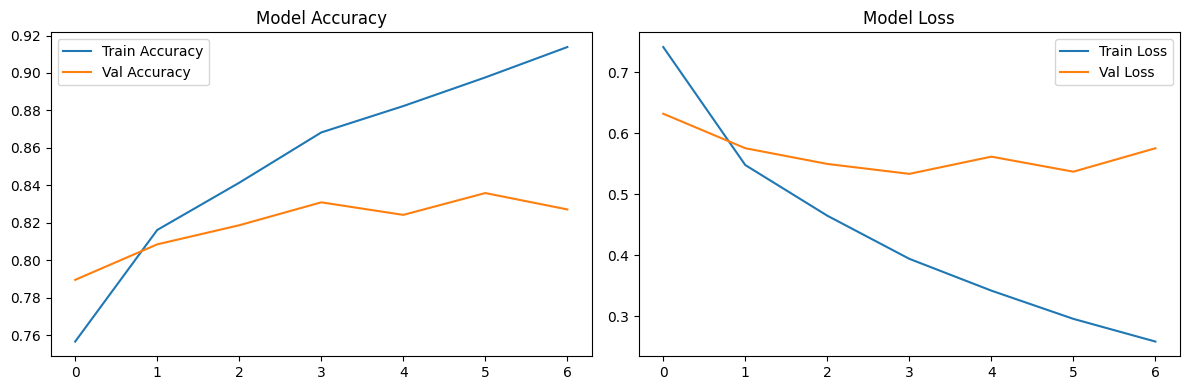

✅ Step 7 Done — Plots shown


In [25]:
# STEP 7: Plot
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],     label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.legend()
plt.tight_layout()
plt.show()
print("✅ Step 7 Done — Plots shown")

In [26]:
# STEP 8: Save
model.save("food11_calorie_model.keras")
print("✅ Step 8 Done — Model saved!")

✅ Step 8 Done — Model saved!


In [27]:
from tensorflow.keras.models import load_model

# Load the model
model = load_model(r"C:\Users\ganes\PycharmProjects\PRODIGY_ML_TaskNumber5\food11_calorie_model.keras")

# Check model summary
model.summary()
print("✅ Model loaded successfully!")

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 11)             │         1,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,754,147 (10.51 MB)

 Trainable params: 165,387 (646.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 330,776 (1.26 MB)

✅ Model loaded successfully!


In [36]:
import kagglehub
import os
import random
import shutil

# Download Food-11 (already cached — instant!)
path = kagglehub.dataset_download("trolukovich/food11-image-dataset")
print("✅ Path:", path)

# Pick a random food image from dataset
eval_dir = os.path.join(path, "evaluation")

# Get all classes
classes = os.listdir(eval_dir)
print("Classes:", classes)

# Pick random class and random image
random_class = random.choice(classes)
class_folder = os.path.join(eval_dir, random_class)
random_image = random.choice(os.listdir(class_folder))
image_path   = os.path.join(class_folder, random_image)

print(f"✅ Random Image : {random_image}")
print(f"✅ Food Class   : {random_class}")
print(f"✅ Image Path   : {image_path}")

# Copy to project folder
project_folder = r"C:\Users\ganes\PycharmProjects\PRODIGY_ML_TaskNumber5"
dest_path = os.path.join(project_folder, "test.jpg")
shutil.copy(image_path, dest_path)
print(f"✅ Image copied to: {dest_path}")

# Now predict!
estimate_calories(dest_path)

✅ Path: C:\Users\ganes\.cache\kagglehub\datasets\trolukovich\food11-image-dataset\versions\1
Classes: ['Bread', 'Dairy product', 'Dessert', 'Egg', 'Fried food', 'Meat', 'Noodles-Pasta', 'Rice', 'Seafood', 'Soup', 'Vegetable-Fruit']
✅ Random Image : 28.jpg
✅ Food Class   : Rice
✅ Image Path   : C:\Users\ganes\.cache\kagglehub\datasets\trolukovich\food11-image-dataset\versions\1\evaluation\Rice\28.jpg
✅ Image copied to: C:\Users\ganes\PycharmProjects\PRODIGY_ML_TaskNumber5\test.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
🍽️  Food     : Rice
📊 Confidence: 99.96%
🔥 Calories  : 206 kcal per 100g


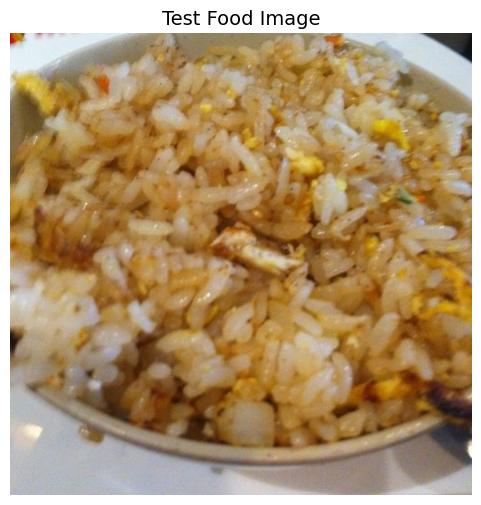

In [38]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Load and display image
img = mpimg.imread(r"C:\Users\ganes\PycharmProjects\PRODIGY_ML_TaskNumber5\test.jpg")

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis('off')
plt.title("Test Food Image", fontsize=14)
plt.show()